In [1]:
pip install pandas scikit-learn matplotlib seaborn # Install required libraries

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc # Import libraries

In [3]:
df = pd.read_csv("customer_subscription_churn_usage_patterns.csv") # Load the dataset

In [4]:
df["churn_flag"] = df["churn"].map({"Yes":1, "No":0}) # Convert churn to numeric 

In [5]:
X = df[[
    "avg_weekly_usage_hours",
    "last_login_days_ago",
    "payment_failures",
    "support_tickets"
]]

y = df["churn_flag"] # Select model variables

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
) # Split training and testing data

In [7]:
model = LogisticRegression()
model.fit(X_train, y_train) # Train the logistic regression model 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
y_prob = model.predict_proba(X_test)[:,1] # Predict churn probability 

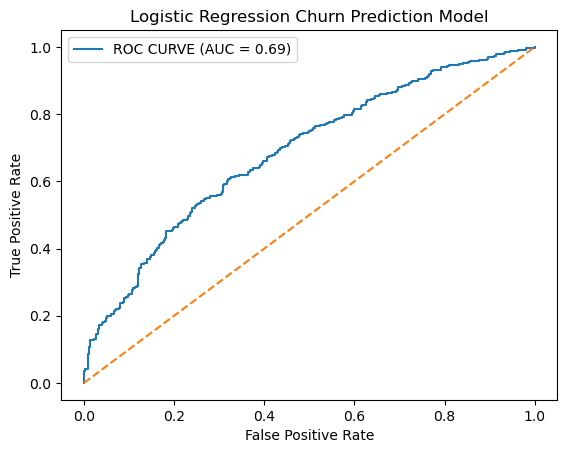

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC CURVE (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate") # False positive rate = (False positives) / (False positives + True negatives)
                                  # False positive rate tells you the proportion of non-churned customers incorrectly classified
                                  # False positives = non-churned customers incorrectly classified as churned
                                  # True negatives = non-churned customers correctly classified as non-churned

plt.ylabel("True Positive Rate") # True positive rate = (True positives) / (True positives + False negatives)
                                 # True positive rate tells you the proportion of churned customers correctly classified
                                 # True positives = churned customers correctly classified as churned
                                 # False negatives = churned customers incorrectly classified as not churned 

plt.title("Logistic Regression Churn Prediction Model")
plt.legend()
plt.show() # Create Receiver Operator Characteristic (ROC) Curve

In [10]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
print(coefficients.sort_values(by = "Coefficient", ascending = False)) # Show feature importance

                  Feature  Coefficient
2        payment_failures     0.295032
3         support_tickets     0.138415
1     last_login_days_ago     0.024796
0  avg_weekly_usage_hours    -0.036349


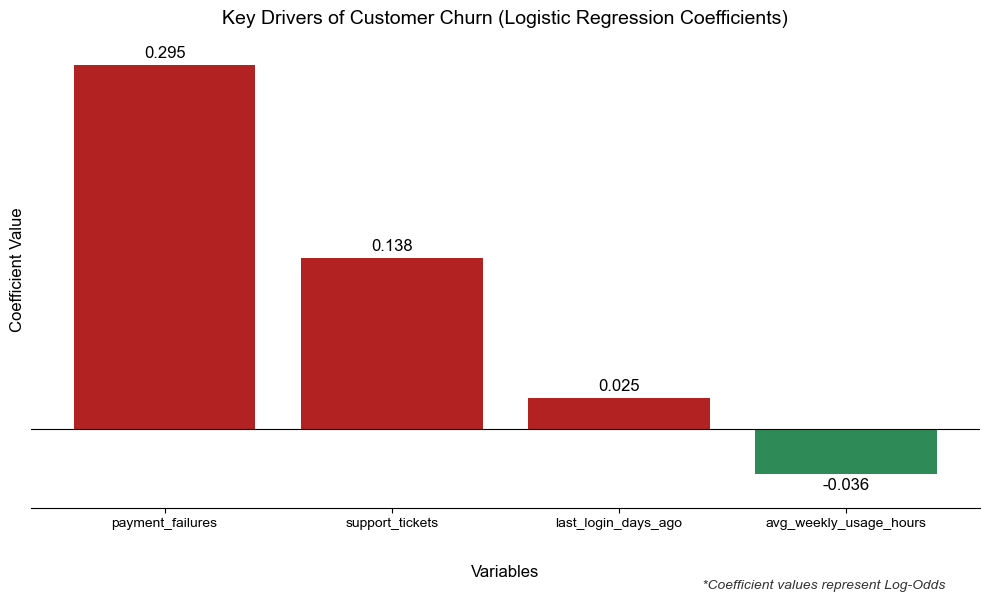

In [11]:
# Set font to Arial

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# 1. Sort the features by coefficient value for a cleaner visual flow
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10, 6))

# 2. Use a color conditional: Red for features increasing churn, Green for decreasing
colors = ['firebrick' if x > 0 else 'seagreen' for x in coefficients['Coefficient']]

bars = plt.bar(coefficients['Feature'], coefficients['Coefficient'], color=colors)

# 3. Clean up the labels and layout
plt.axhline(0, color='black', linewidth=0.8)  # Adds a clear baseline
plt.title("Key Drivers of Customer Churn (Logistic Regression Coefficients)", fontsize=14, pad=15)
plt.xlabel("Variables", fontsize=12, labelpad=25)
plt.ylabel("Coefficient Value", fontsize=12)

# 4. Rotate labels
plt.xticks(rotation=45, ha='right')

# 5. Force the x-axis line to the very bottom of the plot instead of at 0
plt.gca().spines['bottom'].set_position(('outward', 10))

# 6. Set data labels for bars
plt.bar_label(bars, padding=3, fmt='%.3f', fontsize=12)

# 7. Clean up the borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.yticks([])

plt.tight_layout() # Adjusts layout so labels don't get cut off

# Add a note about Log-Odds at the bottom right
plt.figtext(0.95, 0.01, "*Coefficient values represent Log-Odds", 
            horizontalalignment='right', fontsize=10, style='italic', color='black', alpha=0.8)

# Create a dictionary to map old names to new names
rename_map = {
    'payment_failures': 'Payment Failures',
    'support_tickets': 'Support Tickets',
    'last_login_days_ago': 'Recency',
    'avg_weekly_usage_hours': 'Usage'
}

# Rename
coefficients['Feature'] = coefficients['Feature'].replace(rename_map)

plt.savefig("logistic_regression_coefficients_clean.png", bbox_inches="tight", dpi=300)
plt.show()